# Fig: Distribution of last h_actual and Pmax in Infotaxis vs MAP comparison: pmax_th=0.95

Reference: 
- `20260531_fig_infotaxis_MAP_cmp_pmax0.95.ipynb`

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

In [2]:
from data_prep_plot.plot_utils import consolidate_success_num_pings, get_stats
from data_prep_plot.simulation_data_prep import get_success_fname

In [3]:
# Set path
path_data = Path("/Volumes/ssd_2tb_1/infotaxis_simu_2026")

path_fig = Path("../figs_paper_2026")

Samples: left:  989    right:  514
Mean:    left: 0.122  right: 0.826
Median:  left: 0.120  right: 1.006

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  991    right:  545
Mean:    left: 0.189  right: 1.035
Median:  left: 0.149  right: 1.081

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  971    right:  534
Mean:    left: 0.263  right: 1.122
Median:  left: 0.253  right: 1.142

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  976    right:  501
Mean:    left: 0.319  right: 1.421
Median:  left: 0.316  right: 1.556

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------


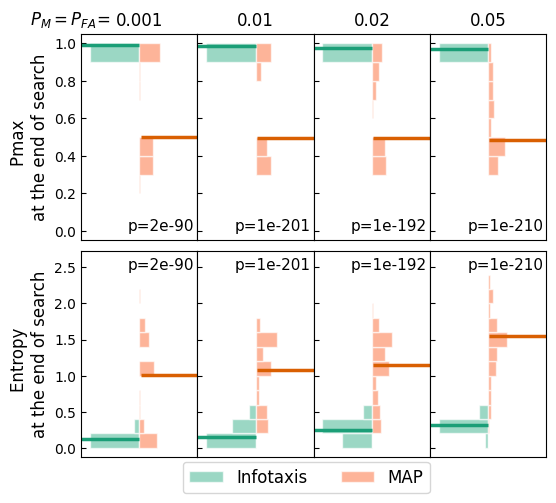

In [4]:
cr = 5
br = 1
pm_all = [0.001, 0.01, 0.02, 0.05]


x_str="Infotaxis"
y_str="MAP"
stats_type="two-sided"
bar_step_h_actual=0.2
bar_step=0.1
crowded_bars=False
colors=sns.color_palette("Set2")
colors_dark=sns.color_palette("Dark2")
color_idx_left=0
color_idx_right=1
alpha = 0.65
print_stats=True

path_left = path_data / "20260530_infotaxis_match_summary_compiled_pmax095_pmaxDiff1e-5"
path_right = path_data / "20260530_MAP_match_summary_compiled_pmax095_pmaxDiff1e-5"
pmax_th = 0.95
pmax_diff_th = 1e-5

df_x_all = []
df_y_all = []
for pm in pm_all:
    # Load summary and ph details
    df_x = pd.read_csv(
        path_left / get_success_fname(
            search_type="infotaxis", cr=cr, br=br, simulation_type="simple",
            pmax_th=pmax_th, pmax_diff_th=pmax_diff_th,
            pm_agent=pm
        ), index_col=0
    )
    df_y = pd.read_csv(
        path_right / get_success_fname(
            search_type="MAP", cr=cr, br=br, simulation_type="simple",
            pmax_th=pmax_th, pmax_diff_th=pmax_diff_th,
            pm_agent=pm
        ), index_col=0
    )
    df_x_all.append(df_x)
    df_y_all.append(df_y)


# Set up fig
fig, axes = plt.subplots(
    2, len(pm_all), figsize=(6, 5.5), sharey="row",
    gridspec_kw={'hspace': 0.05, "wspace": 0}
)

# h_actual
h_actual_bins_max = None
for idx, (pm, df_x, df_y) in enumerate(zip(pm_all, df_x_all, df_y_all)):
    
    # Consolidate success and num_pings: 
    # take the smaller num_pings between pmax_th and pmax_diff criteria
    df_x_filter = consolidate_success_num_pings(df_x)
    df_y_filter = consolidate_success_num_pings(df_y)


    # h_actual ===========================================================

    # Only cound successful runs
    x = df_x_filter[df_x_filter["success"]]["h_actual_final"]
    y = df_y_filter[df_y_filter["success"]]["h_actual_final"]

    # Print statistics
    stats_dict = get_stats(x, y, print_stats=print_stats)


    # Plotting last h_actual distribution
    h_actual_bins = np.arange(0, np.ceil(np.hstack((x, y)).max()/bar_step_h_actual)*bar_step_h_actual+bar_step_h_actual, bar_step_h_actual)
    if h_actual_bins_max is None:
        h_actual_bins_max = h_actual_bins
    else:
        h_actual_bins_max = h_actual_bins if h_actual_bins_max[-1] < h_actual_bins[-1] else h_actual_bins_max


    ax_h = axes[1, idx]  # BOTTOM PANEL

    x_hist, x_bins = np.histogram(x, bins=h_actual_bins, density=True)
    y_hist, y_bins = np.histogram(y, bins=h_actual_bins, density=True)
    x_median = np.median(x)
    y_median = np.median(y)

    if crowded_bars:
        bar_x = ax_h.barh(x_bins[:-1], -x_hist, height=np.diff(x_bins), left=0, align="edge", edgecolor=colors[color_idx_left], color=colors[color_idx_left], alpha=alpha-0.3)
        bar_y = ax_h.barh(y_bins[:-1], y_hist, height=np.diff(x_bins), left=0, align="edge", edgecolor=colors[color_idx_right], color=colors[color_idx_right], alpha=alpha-0.3)
    else:
        bar_x = ax_h.barh(x_bins[:-1], -x_hist, height=np.diff(x_bins), left=0, align="edge", edgecolor="w", color=colors[color_idx_left], alpha=alpha)
        bar_y = ax_h.barh(y_bins[:-1], y_hist, height=np.diff(x_bins), left=0, align="edge", edgecolor="w", color=colors[color_idx_right], alpha=alpha)

    # Get x-axis limits
    xlim = ax_h.get_xlim()
    xlim = np.max([max(xlim), -min(xlim)])
    xlim = xlim + 0.1*np.max(xlim)
    ax_h.set_xlim(-xlim, xlim)
    if crowded_bars:
        ax_h.axhline(x_median, xmin=0.0, xmax=0.5, color=colors_dark[color_idx_left], solid_capstyle="butt", lw=1.5)
        ax_h.axhline(y_median, xmin=0.51, xmax=1, color=colors_dark[color_idx_right], solid_capstyle="butt", lw=1.5)
        ax_h.axvline(0, color="w", lw=1.5)
    else:
        ax_h.axhline(x_median, xmin=0.0, xmax=0.5, color=colors_dark[color_idx_left], solid_capstyle="butt", lw=2.5)
        ax_h.axhline(y_median, xmin=0.51, xmax=1, color=colors_dark[color_idx_right], solid_capstyle="butt", lw=2.5)

    # label sample number
    ax_h.set_xticks([])
    ax_h.set_xticklabels("")

    # label p-value for alternative="less", "greater", or "two-sided"
    ax_h.text(
        0.975, 0.93, f"p={stats_dict[stats_type].pvalue:.0e}",
        ha="right", va="center",
        transform=ax_h.transAxes,
        fontsize=11, 
    )

    ax_h.tick_params(direction='in', which='both')


    # pmax ===========================================================
    # Only cound successful runs
    x = df_x_filter[df_x_filter["success"]]["pmax_final"]
    y = df_y_filter[df_y_filter["success"]]["pmax_final"]

    # Plotting last pmax distribution
    pmax_bins = np.arange(0, 1+bar_step, bar_step)


    ax_p = axes[0, idx]  # TOP PANEL

    x_hist, x_bins = np.histogram(x, bins=pmax_bins, density=True)
    y_hist, y_bins = np.histogram(y, bins=pmax_bins, density=True)
    x_median = np.median(x)
    y_median = np.median(y)

    ax_p.barh(x_bins[:-1], -x_hist, height=np.diff(x_bins), left=0, align="edge", edgecolor="w", color=colors[color_idx_left], alpha=alpha)
    ax_p.barh(y_bins[:-1], y_hist, height=np.diff(x_bins), left=0, align="edge", edgecolor="w", color=colors[color_idx_right], alpha=alpha)        

    # Get x-axis limits
    xlim = ax_p.get_xlim()
    xlim = np.max([max(xlim), -min(xlim)])
    xlim = xlim + 0.1*np.max(xlim)
    ax_p.set_xlim(-xlim, xlim)
    ax_p.axhline(x_median, xmin=0.0, xmax=0.5, color=colors_dark[color_idx_left], solid_capstyle="butt", lw=2.5)
    ax_p.axhline(y_median, xmin=0.51, xmax=1, color=colors_dark[color_idx_right], solid_capstyle="butt", lw=2.5)

    # label sample number
    ax_p.set_xticks([])
    ax_p.set_xticklabels("")

    # label p-value for alternative="less", "greater", or "two-sided"
    ax_p.text(
        0.975, 0.07, f"p={stats_dict[stats_type].pvalue:.0e}",
        ha="right", va="center",
        transform=ax_p.transAxes,
        fontsize=11, 
    )

    ax_p.tick_params(direction='in', which='both')

    # pm values in subpanel title
    ax_p.set_title(f"{pm}")




# add y label
axes[0, 0].set_ylabel("Pmax  \nat the end of search", fontsize=12)
axes[1, 0].set_ylabel("Entropy  \nat the end of search", fontsize=12)

# make title line
axes[0, 0].text(
    -2.75, 1.02, r"$P_M=P_{FA}$=",
    ha="right", va="bottom",
    transform=ax_p.transAxes,
    fontsize=12,
)


# Add single horizontal legend below all panels
fig.legend(
    handles=[bar_x, bar_y],
    labels=[x_str, y_str],
    loc='lower center',
    ncol=2,
    bbox_to_anchor=(0.5, 0.03),
    # frameon=False,
    fontsize=12
)    

plt.show()


fig.savefig(
    path_fig / f"fig_last_pmax_h_actual_infotaxis_MAP_cmp_cr{cr}_br{br}_pmaxTh0.95_pmaxDiff1e-5.png",
    dpi=300, bbox_inches="tight"
)